In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
data = fetch_openml(
    name="Telco-Customer-Churn",
    version=1,
    as_frame=True
)

df = data.frame

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,'No phone service',DSL,No,Yes,No,No,No,No,Month-to-month,Yes,'Electronic check',29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,'One year',No,'Mailed check',56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,'Mailed check',53.85,108.15,Yes
3,Male,0,No,No,45,No,'No phone service',DSL,Yes,No,Yes,Yes,No,No,'One year',No,'Bank transfer (automatic)',42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.70,151.65,Yes


In [3]:
print(df.shape)

print(df.info())

print(df.describe(include="all"))

(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

In [4]:
print(df.isnull().sum())

df = df.fillna(method="ffill")

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_3750/1461066567.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [5]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

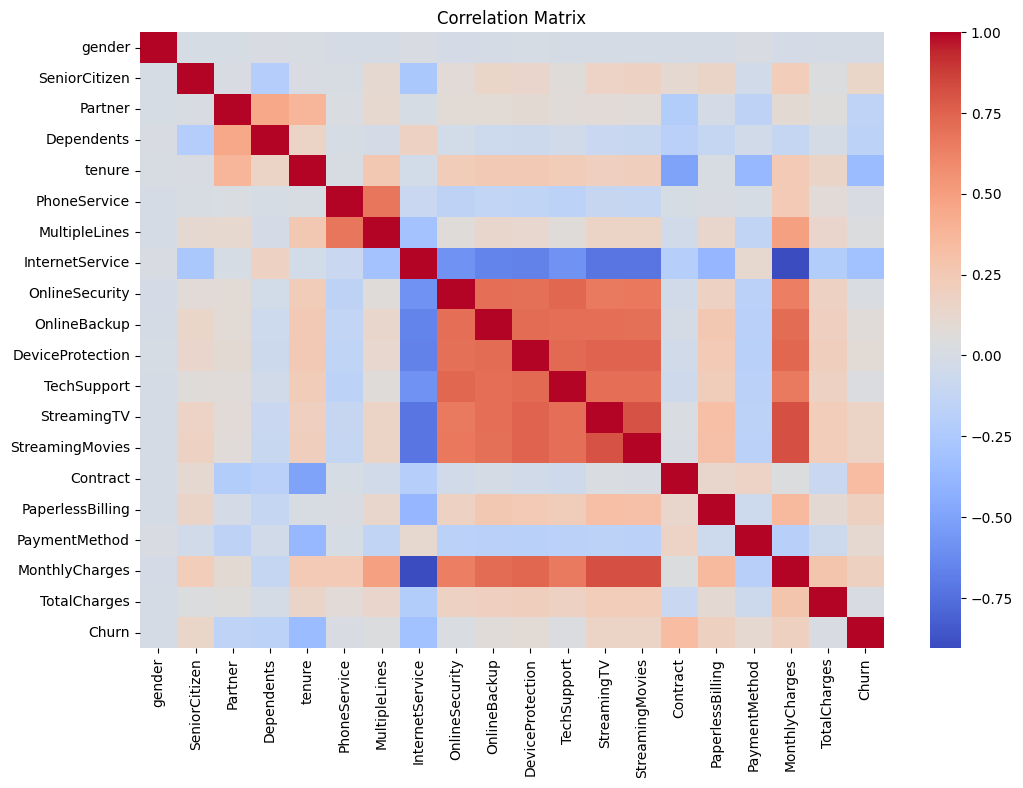

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [7]:
df["MonthlyCharge_Per_Tenure"] = (
    df["MonthlyCharges"] /
    (df["tenure"] + 1)
)

df["TotalCharge_Per_Service"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

In [8]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [10]:
pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.794180269694819


In [11]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1036
           1       0.65      0.49      0.56       373

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



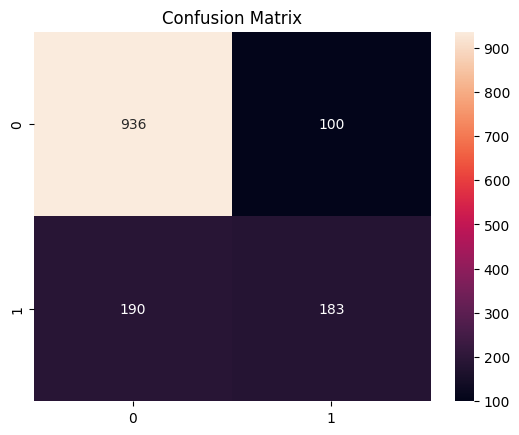

In [12]:
cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.show()

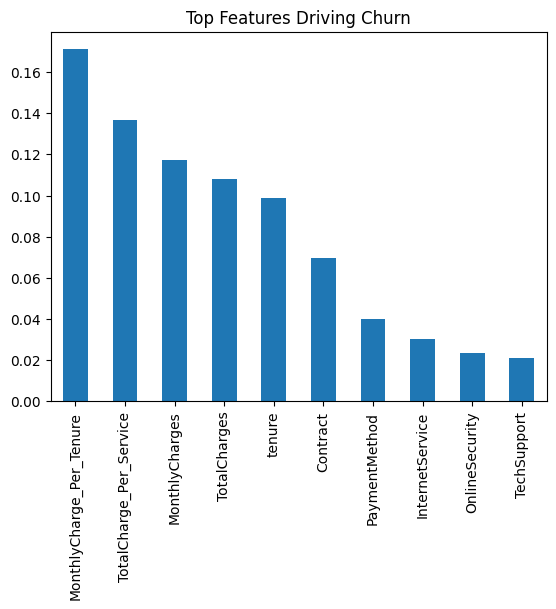

In [13]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title(
    "Top Features Driving Churn"
)

plt.show()

In [14]:
print("="*50)

print(
    "CUSTOMER CHURN ANALYTICS REPORT"
)

print("="*50)

print(
    "\nTotal Customers:",
    len(df)
)

print(
    "\nModel Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

print(
    "\nTop Risk Factors:"
)

print(
    importance.sort_values(
        ascending=False
    ).head(5)
)

CUSTOMER CHURN ANALYTICS REPORT

Total Customers: 7043

Model Accuracy: 79.42 %

Top Risk Factors:
MonthlyCharge_Per_Tenure    0.171047
TotalCharge_Per_Service     0.136581
MonthlyCharges              0.117189
TotalCharges                0.108177
tenure                      0.098686
dtype: float64
